In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Chocolate Sales.csv")
print("Done")

Done


In [ ]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [ ]:
print("Dataset Size:\n",df.shape)

Dataset Size:
 (1094, 6)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


No null values.
Must change data types of Date column to datetime and Amount coulmn into int after removing '$' and ','.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%b-%y")

In [ ]:
df['Amount'] = df['Amount'].str.split("$").str[1]

In [ ]:
df['Amount'] = df['Amount'].str.replace(',', '', regex=False)

In [ ]:
df['Amount'] = df['Amount'].astype(int)

In [ ]:
print('Data Types of Coulmns:\n',df.dtypes)

Data Types of Coulmns:
 Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                    int64
Boxes Shipped             int64
dtype: object


In [ ]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [ ]:
print("Duplicate Values:\n", df.duplicated().sum())

Duplicate Values:
 0


In [ ]:
df.describe(include = 'all')

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,1094,1094,1094,1094,1094.000000,1094.000000
unique,25,6,22,NaN,NaN,NaN
top,Kelci Walkden,Australia,Eclairs,NaN,NaN,NaN
freq,54,205,60,NaN,NaN,NaN
mean,NaN,NaN,NaN,2022-05-03 09:04:56.160877568,5652.308044,161.797989
min,NaN,NaN,NaN,2022-01-03 00:00:00,7.000000,1.000000
25%,NaN,NaN,NaN,2022-03-02 00:00:00,2390.500000,70.000000
50%,NaN,NaN,NaN,2022-05-11 00:00:00,4868.500000,135.000000
75%,NaN,NaN,NaN,2022-07-04 00:00:00,8027.250000,228.750000
max,NaN,NaN,NaN,2022-08-31 00:00:00,22050.000000,709.000000


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()

In [ ]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,Day
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320,180,2022,January,Tuesday
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896,94,2022,August,Monday
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501,91,2022,July,Thursday
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726,342,2022,April,Wednesday
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685,184,2022,February,Thursday


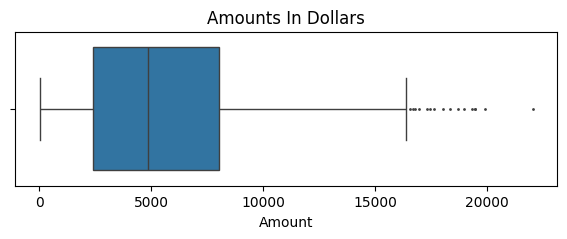

In [ ]:
plt.figure(figsize=(7,2))
plt.title('Amounts In Dollars')
sns.boxplot(x=df['Amount'], fliersize=1);

The box plot shows that:

Median Value: The typical order amount is approximatel $4,800 representing the typical price for a single order.

Interquartile Range (IQR): Orders between $2,500 and $8,000 represent approximately 50% of the sales. indicating the core market segment.

High-Value Outliers: The anomalies ranging from $17,000 to over $22,000. These significantly exceed the standard transaction size.

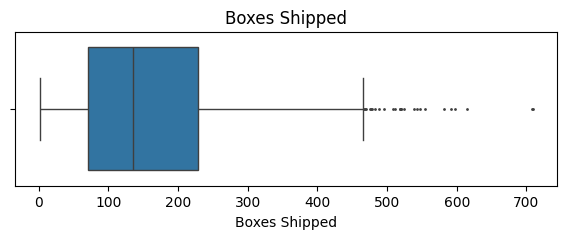

In [ ]:
plt.figure(figsize=(7,2))
plt.title('Boxes Shipped')
sns.boxplot(x=df['Boxes Shipped'], fliersize=1);

The box plot shows that:

Median Value: The median shipment size 135 boxes, which represents the typical number of boxes shipped per order.

Interquartile Range (IQR): Boxes between 70 and 228 boxes represent approximately 50% of the boxes shipped. showing consistent mid-range market.

High-Value Outliers: The anomalies ranging from 470 to over 700 boxes. These represent very large number of boxes that deviate from standard operations.

In [ ]:
print("Total Sales Persons:", df['Sales Person'].nunique())

Total Sales Persons: 25


In [ ]:
print("Total Countries:", df['Country'].nunique())

Total Countries: 6


In [ ]:
print("Total Products:", df['Product'].nunique())

Total Products: 22


In [ ]:
print("Total Amount:", f"${df['Amount'].sum():,}")

Total Amount: $6,183,625


In [ ]:
print("Total Boxes Shipped:", f"{df['Boxes Shipped'].sum():,}")

Total Boxes Shipped: 177,007


In [ ]:
Sale_Person_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
print("Sale Person and thier total sales:\n",Sale_Person_sales)

Sale Person and thier total sales:
 Sales Person
Ches Bonnell           320901
Oby Sorrel             316645
Madelene Upcott        316099
Brien Boise            312816
Kelci Walkden          311710
Van Tuxwell            303149
Dennison Crosswaite    291669
Beverie Moffet         278922
Kaine Padly            266490
Marney O'Breen         259742
Barr Faughny           258713
Roddy Speechley        251062
Gunar Cockshoot        238483
Gigi Bohling           232666
Karlen McCaffrey       223895
Jehu Rudeforth         220976
Jan Morforth           219667
Curtice Advani         216461
Rafaelita Blaksland    210245
Husein Augar           205212
Andria Kimpton         201747
Mallorie Waber         200592
Camilla Castle         196616
Dotty Strutley         190624
Wilone O'Kielt         138523
Name: Amount, dtype: int64


In [ ]:
print("Top 5 Sales Person:\n",Sale_Person_sales.head(5))

Top 5 Sales Person:
 Sales Person
Ches Bonnell       320901
Oby Sorrel         316645
Madelene Upcott    316099
Brien Boise        312816
Kelci Walkden      311710
Name: Amount, dtype: int64


/tmp/ipykernel_2710/1682497446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_5_sales.index, y=top_5_sales.values, palette="rocket")


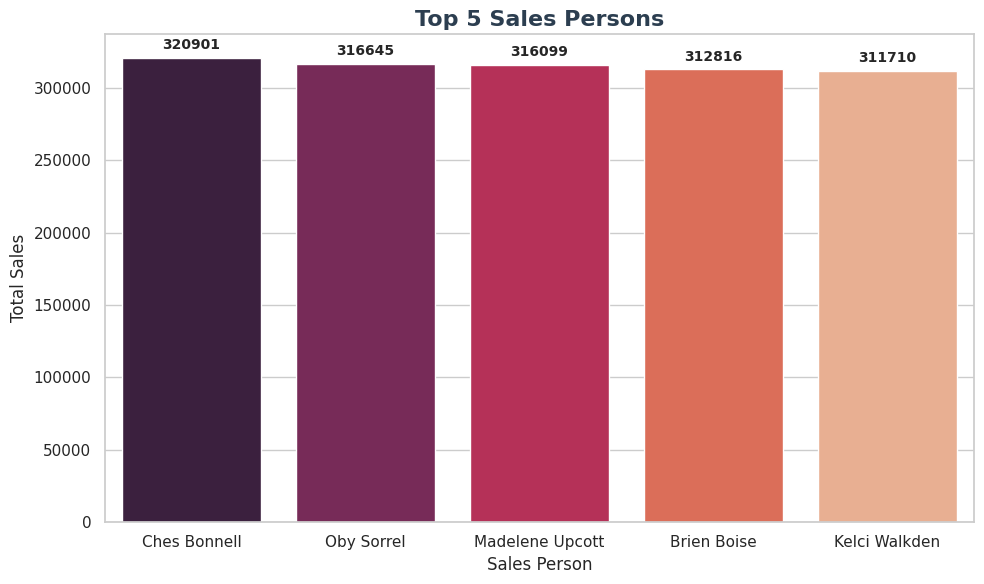

In [ ]:
top_5_sales = Sale_Person_sales.head(5)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_5_sales.index, y=top_5_sales.values, palette="rocket")
plt.title('Top 5 Sales Persons', fontsize=16, fontweight='bold', color='#2c3e50')
plt.xlabel('Sales Person', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

In [ ]:
Country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
print("Countries and thier sales:",Country_sales)

Countries and thier sales: Country
Australia      1137367
UK             1051792
India          1045800
USA            1035349
Canada          962899
New Zealand     950418
Name: Amount, dtype: int64


/tmp/ipykernel_2710/3412030306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=Country_sales.index, y=Country_sales.values, palette="viridis")


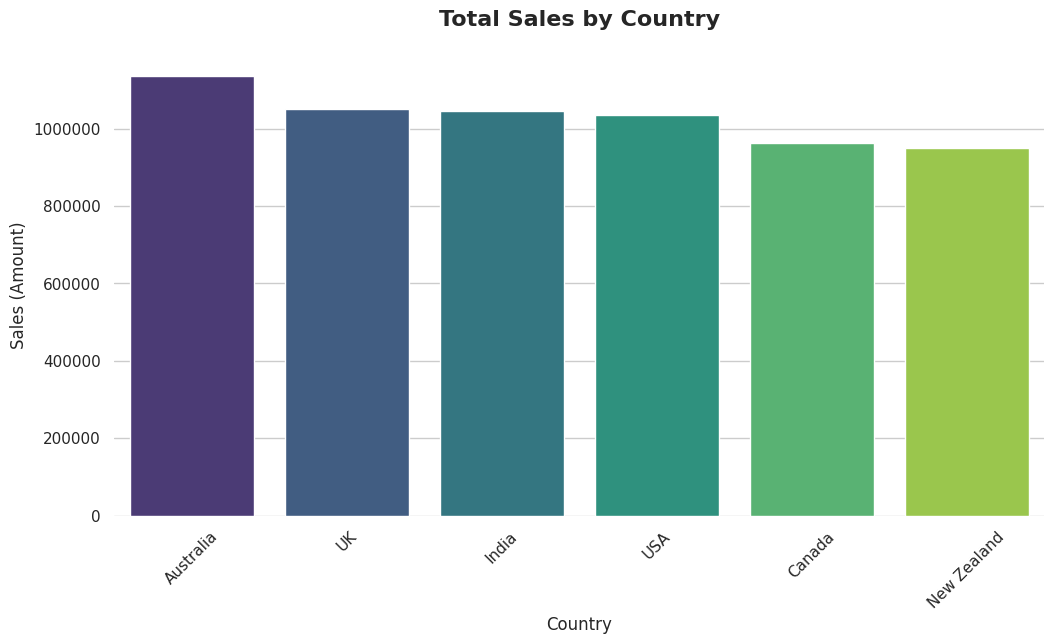

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
plot = sns.barplot(x=Country_sales.index, y=Country_sales.values, palette="viridis")
plt.title('Total Sales by Country', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Sales (Amount)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)
plt.show()

In [ ]:
Product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print("Products and thier sales:",Product_sales)

Products and thier sales: Product
Smooth Sliky Salty      349692
50% Dark Bites          341712
White Choc              329147
Peanut Butter Cubes     324842
Eclairs                 312445
99% Dark & Pure         299796
85% Dark Bars           299229
Organic Choco Syrup     294700
Spicy Special Slims     293454
Mint Chip Choco         283969
Almond Choco            277536
Manuka Honey Choco      275541
Milk Bars               269248
Raspberry Choco         264740
After Nines             261331
Fruit & Nut Bars        259147
Drinking Coco           256655
Orange Choco            256144
Baker's Choco Chips     249613
Choco Coated Almonds    241486
Caramel Stuffed Bars    231588
70% Dark Bites          211610
Name: Amount, dtype: int64


/tmp/ipykernel_2710/2298365232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_5_products.index, y=top_5_products.values, palette="mako")


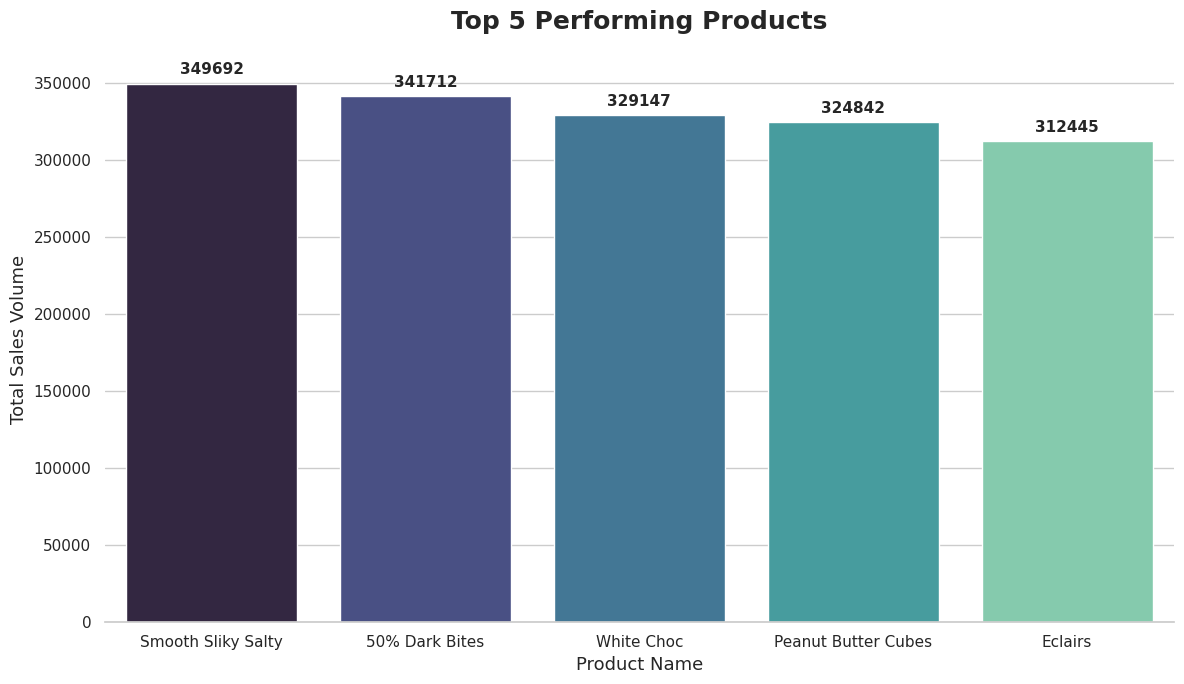

In [ ]:
top_5_products = Product_sales.head(5)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=top_5_products.index, y=top_5_products.values, palette="mako")
plt.title('Top 5 Performing Products', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Product Name', fontsize=13)
plt.ylabel('Total Sales Volume', fontsize=13)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='semibold')

plt.ticklabel_format(style='plain', axis='y')
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [ ]:
boxes_of_product = df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False)
print(boxes_of_product)

Product
50% Dark Bites          9792
Smooth Sliky Salty      8810
Eclairs                 8757
Caramel Stuffed Bars    8717
Spicy Special Slims     8685
Drinking Coco           8660
Milk Bars               8330
Peanut Butter Cubes     8304
After Nines             8257
White Choc              8240
Mint Chip Choco         8207
99% Dark & Pure         8127
70% Dark Bites          8015
85% Dark Bars           7793
Manuka Honey Choco      7781
Organic Choco Syrup     7749
Fruit & Nut Bars        7738
Orange Choco            7732
Raspberry Choco         7115
Baker's Choco Chips     6998
Almond Choco            6736
Choco Coated Almonds    6464
Name: Boxes Shipped, dtype: int64


/tmp/ipykernel_2710/2603447260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_5_boxes.values, y=top_5_boxes.index, palette="flare")


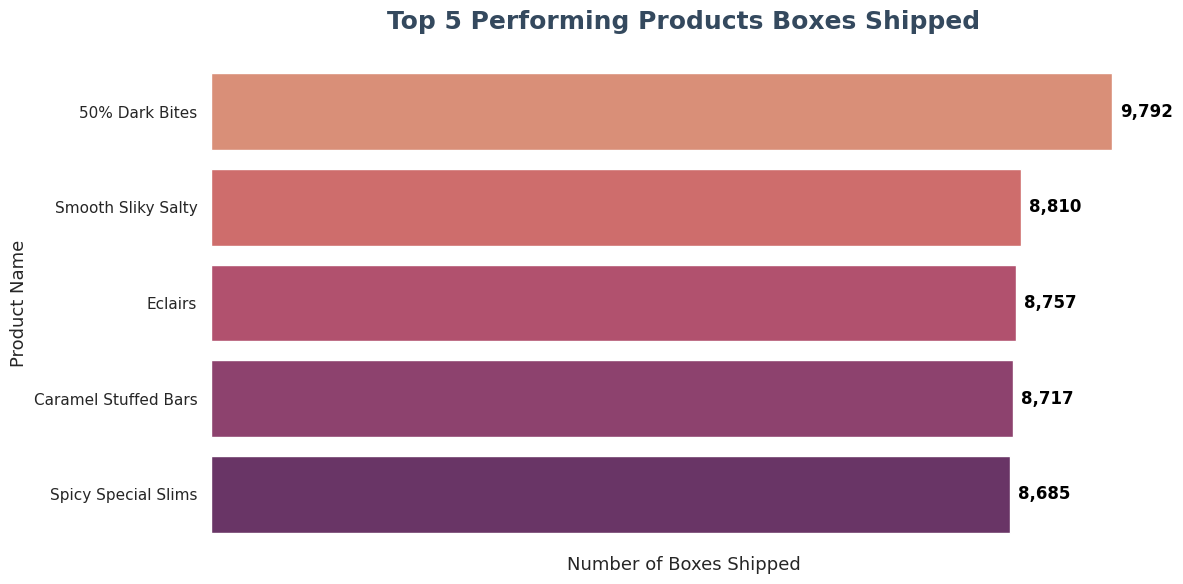

In [ ]:
top_5_boxes = boxes_of_product.head(5)
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_5_boxes.values, y=top_5_boxes.index, palette="flare")
plt.title('Top 5 Performing Products Boxes Shipped', fontsize=18, fontweight='bold', pad=25, color='#34495e')
plt.xlabel('Number of Boxes Shipped', fontsize=13, labelpad=10)
plt.ylabel('Product Name', fontsize=13)

for i, v in enumerate(top_5_boxes.values):
    ax.text(v + (v * 0.01), i, f'{int(v):,}', color='black', va='center', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.xticks([])
plt.tight_layout()

plt.show()

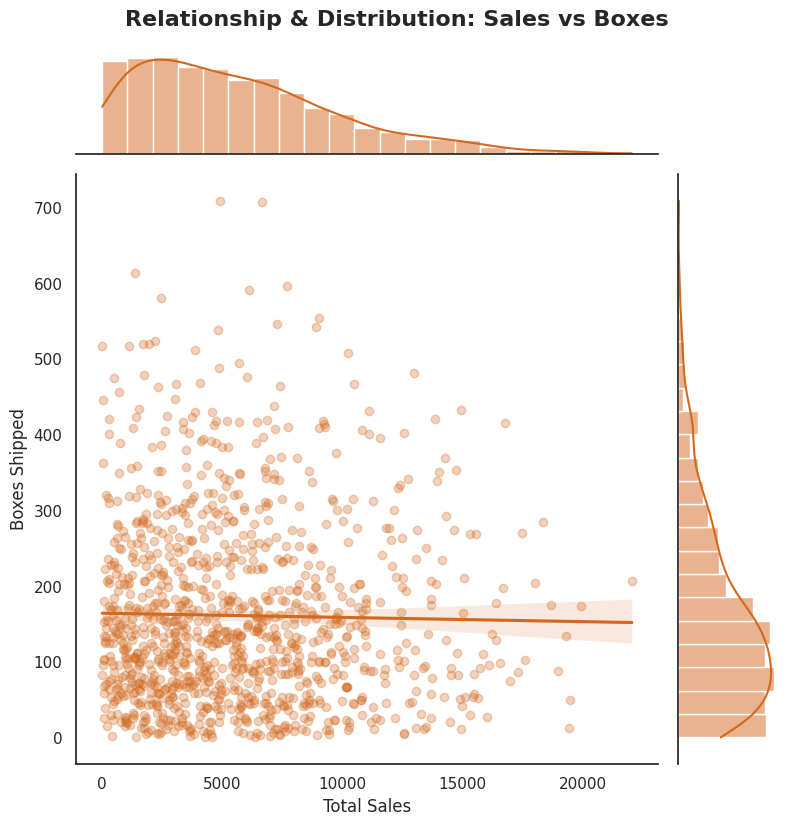

In [ ]:
g = sns.jointplot(data=df, x='Amount', y='Boxes Shipped',
                  kind="reg",
                  color="chocolate",
                  scatter_kws={'alpha':0.3},
                  height=8)

g.fig.suptitle('Relationship & Distribution: Sales vs Boxes', fontsize=16, fontweight='bold', y=1.03)
g.set_axis_labels('Total Sales', 'Boxes Shipped', fontsize=12)

plt.show()

The Relationship Between The Number of Boxes Shipped And The Total Sales Smount:

The relationship is very weak; higher sales don't always mean more boxes shipped.

Most data points are below 10k sales and 300 boxes.

Some high-value sales involve fewer boxes (premium products).

In [ ]:
print("Sales bt the year:\n", df.groupby('Year')['Amount'].sum())

Sales bt the year:
 Year
2022    6183625
Name: Amount, dtype: int64


In [ ]:
Month_sales = df.groupby('Month')['Amount'].sum().sort_values(ascending=False)
print("Sales bt the months:\n", Month_sales)

Sales bt the months:
 Month
January     896105
June        865144
July        803425
May         752892
March       749483
August      743148
February    699377
April       674051
Name: Amount, dtype: int64


In [ ]:
months_order = ["January", "February", "March", "April", "May", "June", "July", "August"]
Month_sales = Month_sales.reindex(months_order)

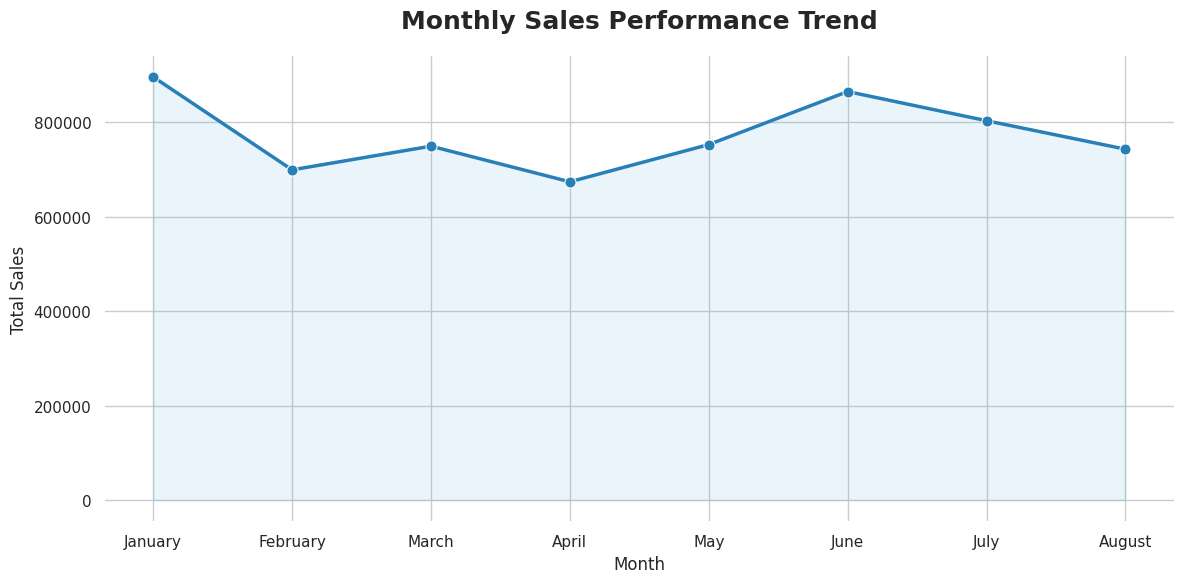

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
# Convert the Series to a DataFrame for seaborn to correctly interpret x and y
Month_sales_df = Month_sales.reset_index()
Month_sales_df.columns = ['Month', 'Amount']

ax = sns.lineplot(data=Month_sales_df, x='Month', y='Amount',
                  marker='o', markersize=8, linewidth=2.5, color='#2980b9')
plt.fill_between(Month_sales_df['Month'], Month_sales_df['Amount'], color='#3498db', alpha=0.1)

plt.title('Monthly Sales Performance Trend', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
Daily_sales = df.groupby('Day')['Amount'].sum().sort_values(ascending=False)
print("Sales by the days:\n", Daily_sales)

Sales by the days:
 Day
Monday       1385783
Tuesday      1286719
Thursday     1244789
Wednesday    1204560
Friday       1061774
Name: Amount, dtype: int64


In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Daily_sales = Daily_sales.reindex(day_order)

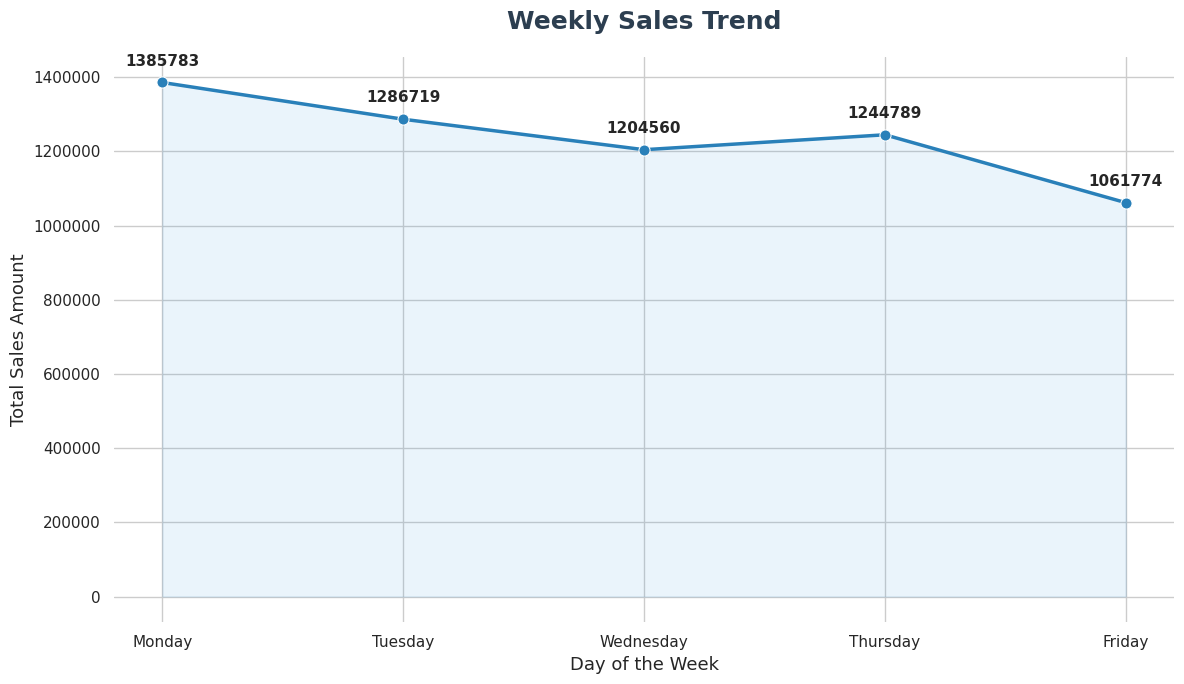

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Convert the Series to a DataFrame for seaborn to correctly interpret x and y
Daily_sales_df = Daily_sales.reset_index()
Daily_sales_df.columns = ['Day', 'Amount']

ax = sns.lineplot(data=Daily_sales_df, x='Day', y='Amount',
                  marker='o', markersize=8, linewidth=2.5, color='#2980b9')

# Fill the area under the line
plt.fill_between(Daily_sales_df['Day'], Daily_sales_df['Amount'], color='#3498db', alpha=0.1)

plt.title('Weekly Sales Trend', fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Day of the Week', fontsize=13)
plt.ylabel('Total Sales Amount', fontsize=13)

# Annotate each point
for index, row in Daily_sales_df.iterrows():
    if pd.notna(row['Amount']): # Only annotate if there is an amount
        ax.annotate(f"{row['Amount']:.0f}",
                    (row['Day'], row['Amount']),
                    textcoords="offset points",
                    xytext=(0,10), # distance from text to points (x,y)
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ticklabel_format(style='plain', axis='y')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
output_filename = 'processed_chocolate_sales.csv'
df.to_csv(output_filename, index=False)
print(f"DataFrame saved to {output_filename}")

DataFrame saved to processed_chocolate_sales.csv
